# 1. Import library


In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import os

# 2. Data Preprocessing


In [2]:
def process_data_final(file_path, num_points=100):
    if not os.path.exists(file_path): 
        raise FileNotFoundError(f'File not found: {file_path}')
        
    df = pd.read_csv(file_path, on_bad_lines='skip', skip_blank_lines=True)
    
    # تنظيف أسماء الأعمدة من المسافات الزائدة لتجنب أي خطأ في الأسماء
    df.columns = df.columns.str.strip()
    
    df['Model_ID'] = pd.to_numeric(df['Model_ID'], errors='coerce')
    # df = df.dropna(subset=['Model_ID'])
    
    ids = df['Model_ID'].unique()
    X, y_thrust, y_pressure, y_scalars = [], [], [], []

    for uid in ids:
        try:
            case_data = df[df['Model_ID'] == uid].sort_values('Time (s)')
            
            # تم تعديل Diameter ليكون بدون مسافة بناءً على عملية التنظيف أعلاه
            inputs = case_data[['Length', 'Diameter', 'Core_Diameter', 'Throat_Diameter', 'Exit_Diameter']].iloc[0].values
            t = case_data['Time (s)'].values
            
            if len(t) < 2 or t[-1] <= 0 or np.any(inputs <= 0): 
                continue

            thrust = case_data['Thrust (N)'].fillna(0).values
            pressure = case_data['Pressure (MPa)'].fillna(0).values

            if len(thrust) > 7:
                thrust = savgol_filter(thrust, window_length=7, polyorder=3)
                pressure = savgol_filter(pressure, window_length=7, polyorder=3)

            x_new = np.linspace(t[0], t[-1], num_points)
            X.append(inputs)
            y_thrust.append(interp1d(t, thrust, kind='linear', fill_value='extrapolate')(x_new))
            y_pressure.append(interp1d(t, pressure, kind='linear', fill_value='extrapolate')(x_new))
            
            # استدعاء أسماء الأعمدة الخاصة بالـ ISP والـ Total Impulse
            y_scalars.append([case_data['ISP (s)'].iloc[0], case_data['Total Impulse (Ns)'].iloc[0], t[-1], np.max(thrust)])
            
        except Exception: 
            continue
        
    return np.array(X), np.array(y_thrust), np.array(y_pressure), np.array(y_scalars)

# Downloading and Processing Data
X, yt, yp, ys = process_data_final('/kaggle/input/datasets/mahmoudabdelrazek11/bates1/Final_data_bates.csv') 
X, yt, yp, ys = X.astype(float), yt.astype(float), yp.astype(float), ys.astype(float)
min_s = min(len(X), len(yt), len(yp), len(ys))
X, yt, yp, ys = X[:min_s], yt[:min_s], yp[:min_s], ys[:min_s]

X_train, X_test, yt_train, yt_test, yp_train, yp_test, ys_train, ys_test = train_test_split(X, yt, yp, ys, test_size=0.15, random_state=42)

s_X = RobustScaler(); X_tr_s = s_X.fit_transform(X_train); X_te_s = s_X.transform(X_test)
s_yt, s_yp, s_ys = StandardScaler(), StandardScaler(), StandardScaler()
yt_tr_s, yp_tr_s, ys_tr_s = s_yt.fit_transform(yt_train), s_yp.fit_transform(yp_train), s_ys.fit_transform(ys_train)

print(f"The data has been loaded successfully {len(X)} cases.")

The data has been loaded successfully 4011 cases.


# 3. DL Model Architecture


In [3]:

input_l = layers.Input(shape=(5,))
x = layers.Dense(512, activation='relu')(input_l)
x = layers.BatchNormalization()(x)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.1)(x)
shared = layers.Dense(1024, activation='relu')(x)

def branch(nodes, out, name):
    b = layers.Dense(nodes, activation='relu')(shared)
    b = layers.BatchNormalization()(b)
    b = layers.Dense(nodes, activation='relu')(b)
    b = layers.Dense(nodes // 2, activation='relu')(b) 
    return layers.Dense(out, name=name)(b)

model = Model(inputs=input_l, outputs=[branch(512, 100, 'Thrust'), branch(512, 100, 'Pressure'), branch(256, 4, 'Scalars')])

model.compile(optimizer=Adam(0.002), loss='huber', metrics=['mae', 'mae', 'mae'])

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5)
early_stopping = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True)

history = model.fit(X_tr_s, [yt_tr_s, yp_tr_s, ys_tr_s],
          validation_split=0.15,
          epochs=300, batch_size=32, verbose=1,
          callbacks=[early_stopping, lr_scheduler])

2026-05-03 22:36:52.700501: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/300
91/91 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - Pressure_loss: 0.1551 - Pressure_mae: 0.4146 - Scalars_loss: 0.1464 - Scalars_mae: 0.3986 - Thrust_loss: 0.1376 - Thrust_mae: 0.3854 - loss: 0.4391 - val_Pressure_loss: 0.3492 - val_Pressure_mae: 0.7157 - val_Scalars_loss: 0.3331 - val_Scalars_mae: 0.6857 - val_Thrust_loss: 0.3139 - val_Thrust_mae: 0.6647 - val_loss: 0.9962 - learning_rate: 0.0020
Epoch 2/300
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - Pressure_loss: 0.0488 - Pressure_mae: 0.2398 - Scalars_loss: 0.0470 - Scalars_mae: 0.2289 - Thrust_loss: 0.0442 - Thrust_mae: 0.2183 - loss: 0.1400 - val_Pressure_loss: 0.3117 - val_Pressure_mae: 0.6762 - val_Scalars_loss: 0.3309 - val_Scalars_mae: 0.6843 - val_Thrust_loss: 0.3026 - val_Thrust_mae: 0.6665 - val_loss: 0.9452 - learning_rate: 0.0020
Epoch 3/300
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - Pressure_loss: 0.0352 - Pressure_mae: 0.1997 - Scalars_loss: 0.0356 - Scalars_mae: 0.2007 - Thrust_loss: 0.0364 - Thrust_mae: 0.2022 - los

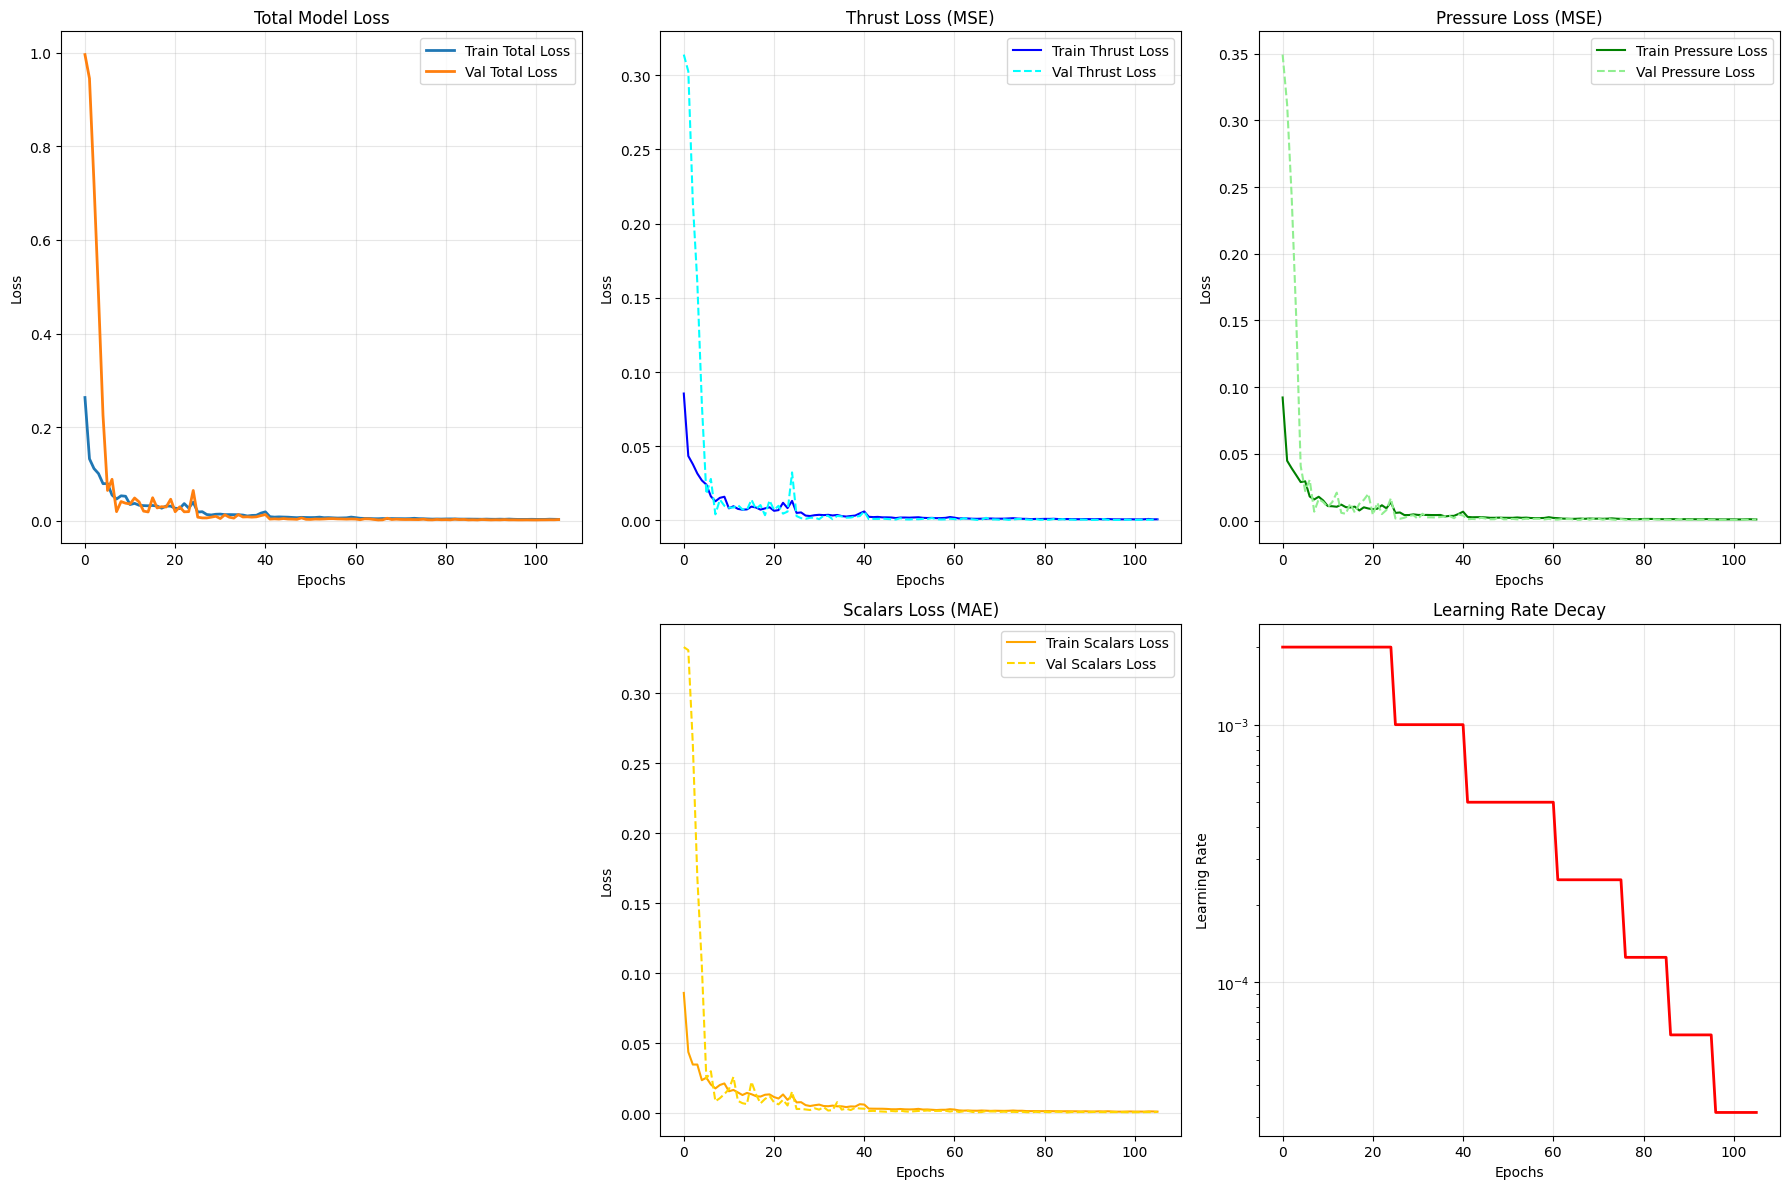

In [4]:
#  (Loss Curves) 
plt.figure(figsize=(18, 12))

# 1. Total Loss 
plt.subplot(2, 3, 1)
plt.plot(history.history['loss'], label='Train Total Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Total Loss', linewidth=2)
plt.title('Total Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Thrust Loss
plt.subplot(2, 3, 2)
plt.plot(history.history['Thrust_loss'], label='Train Thrust Loss', color='blue')
plt.plot(history.history['val_Thrust_loss'], label='Val Thrust Loss', color='cyan', linestyle='--')
plt.title('Thrust Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Pressure Loss
plt.subplot(2, 3, 3)
plt.plot(history.history['Pressure_loss'], label='Train Pressure Loss', color='green')
plt.plot(history.history['val_Pressure_loss'], label='Val Pressure Loss', color='lightgreen', linestyle='--')
plt.title('Pressure Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)


# 4. Scalars Loss 
plt.subplot(2, 3, 5)
plt.plot(history.history['Scalars_loss'], label='Train Scalars Loss', color='orange')
plt.plot(history.history['val_Scalars_loss'], label='Val Scalars Loss', color='gold', linestyle='--')
plt.title('Scalars Loss (MAE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# 5. Learning Rate
plt.subplot(2, 3, 6)
plt.plot(history.history['learning_rate'], color='red', linewidth=2)
plt.title('Learning Rate Decay')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.grid(True, alpha=0.3)
plt.yscale('log') # نستخدم مقياس لوغاريتمي لرؤية التغيرات الصغيرة

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


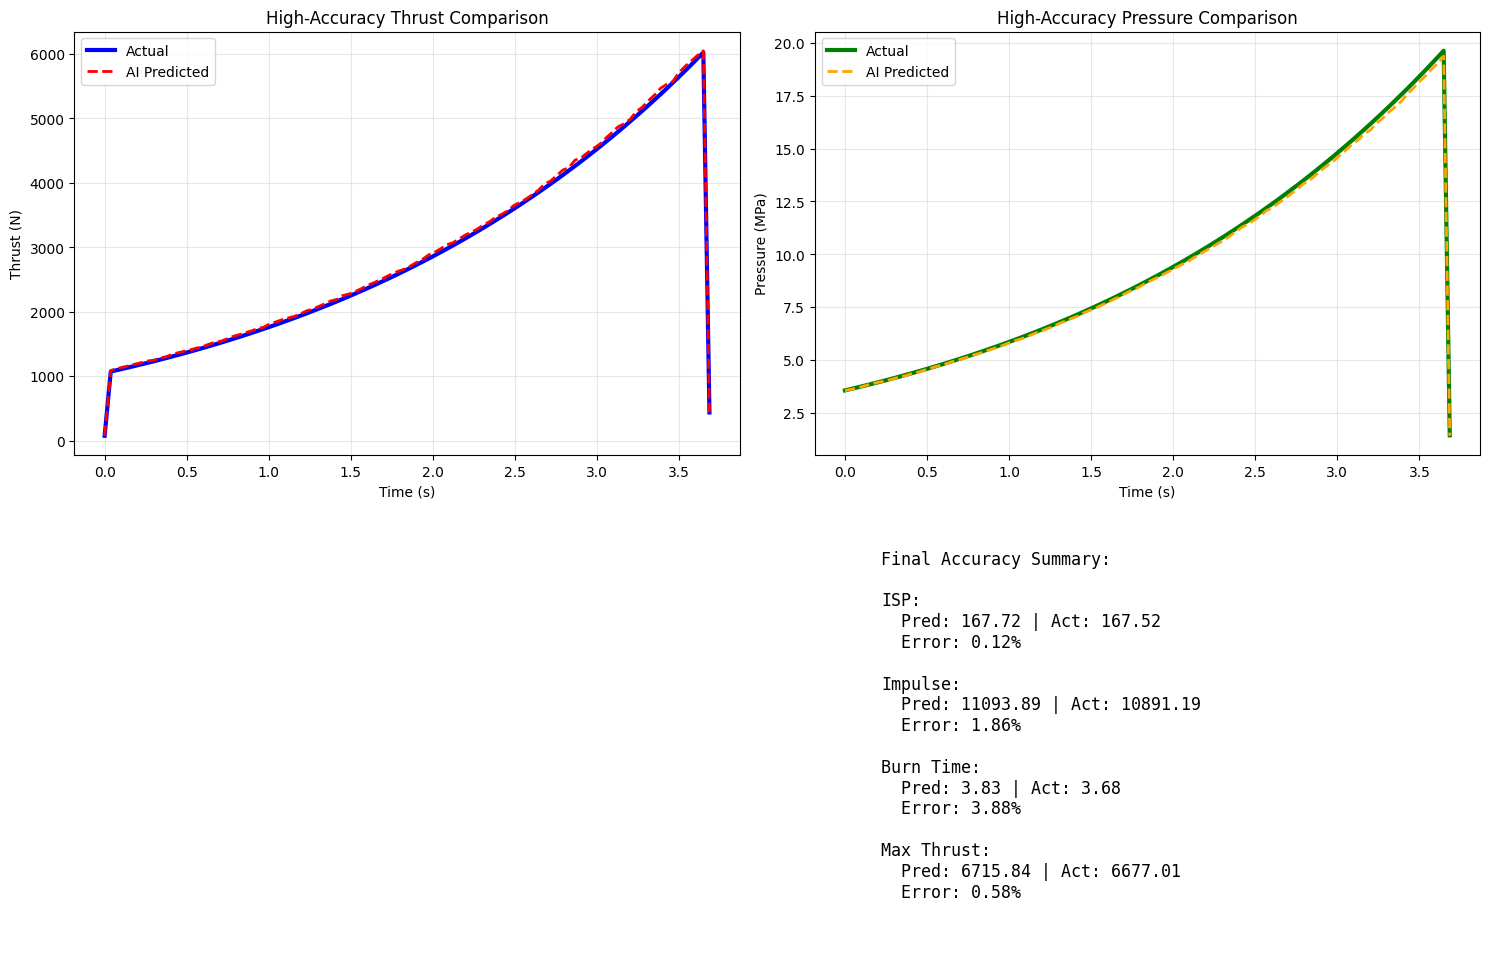

In [5]:
# 3. Drawing and precise comparison
sample_idx = 200

sample_input = X_te_s[sample_idx:sample_idx+1]

preds = model.predict(sample_input)

pred_thrust = s_yt.inverse_transform(preds[0])[0]
pred_pressure = s_yp.inverse_transform(preds[1])[0]
pred_scalars = s_ys.inverse_transform(preds[2])[0]

act_thrust = yt_test[sample_idx]
act_pressure = yp_test[sample_idx]
act_scalars = ys_test[sample_idx]


time_axis = np.linspace(0, act_scalars[2], 100)

plt.figure(figsize=(15, 10))

# Thrust Plot
plt.subplot(2, 2, 1)
plt.plot(time_axis, act_thrust, 'b-', label='Actual', linewidth=3)

plt.plot(time_axis, pred_thrust, 'r--', label='AI Predicted', linewidth=2)
plt.title('High-Accuracy Thrust Comparison')
plt.xlabel('Time (s)')
plt.ylabel('Thrust (N)')
plt.legend()
plt.grid(True, alpha=0.3)

# Pressure Plot
plt.subplot(2, 2, 2)
plt.plot(time_axis, act_pressure, 'g-', label='Actual', linewidth=3)
plt.plot(time_axis, pred_pressure, 'orange', linestyle='--', label='AI Predicted', linewidth=2)
plt.title('High-Accuracy Pressure Comparison')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (MPa)')
plt.legend()
plt.grid(True, alpha=0.3)


# Error Summary
plt.subplot(2, 2, 4)
plt.axis('off')
labels = ['ISP', 'Impulse', 'Burn Time', 'Max Thrust']
summary_text = "Final Accuracy Summary:\n\n"
for i, label in enumerate(labels):
    error = abs(pred_scalars[i] - act_scalars[i]) / (act_scalars[i] + 1e-9) * 100
    summary_text += f"{label}:\n  Pred: {pred_scalars[i]:.2f} | Act: {act_scalars[i]:.2f}\n  Error: {error:.2f}%\n\n"
plt.text(0.1, 0.5, summary_text, fontsize=12, family='monospace', va='center')

plt.tight_layout()
plt.show()


In [6]:

model.save('Bates_model.keras')

# احفظ الـ 4 Scalers
joblib.dump(s_X,  'scaler_X.pkl')
joblib.dump(s_yt, 'scaler_thrust.pkl')
joblib.dump(s_yp, 'scaler_pressure.pkl')
joblib.dump(s_ys, 'scaler_scalars.pkl')

print("Model + Scalers saved ")

Model + Scalers saved 



--- Enter the dimensions of the Bates Grain for prediction ---


Length:  58
Outer Diameter:  14
Inner Diameter (Core):  12
Throat Diameter:  1.4
Exit Diameter:  2.4


/tmp/ipykernel_57/3956301938.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  calculated_impulse = np.trapz(thrust_pred[0], time_steps)



----------------------------------------
--- Predicted Performance Results ---
----------------------------------------
ISP: 165.29 s
Total Impulse (Calculated): 6149.88 N.s
Burn Time: 0.83 s
Max Thrust: 11747.45 N
----------------------------------------



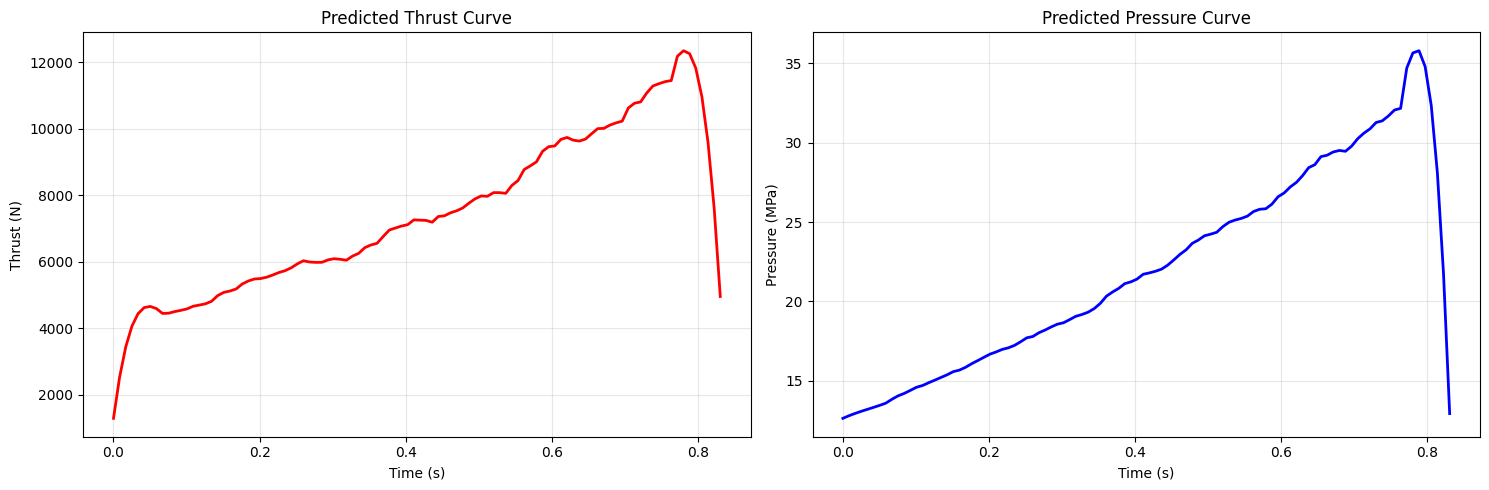

In [9]:
def get_user_input_and_predict_bates():
    print("\n" + "="*50)
    print("--- Enter the dimensions of the Bates Grain for prediction ---")
    print("="*50)
    try:
        # 1. استلام المدخلات
        l_val = float(input("Length: "))
        o_d_val = float(input("Outer Diameter: "))
        i_d_val = float(input("Inner Diameter (Core): "))
        t_d_val = float(input("Throat Diameter: "))
        e_d_val = float(input("Exit Diameter: "))
        
        # Input arrangement (يجب أن يكون بنفس الترتيب الذي تم تدريب النموذج عليه)
        user_inputs = np.array([[l_val, o_d_val, i_d_val, t_d_val, e_d_val]])
        user_inputs_scaled = s_X.transform(user_inputs)
        
        # 2. Prediction
        # سيتم استخدام النموذج (model) الموجود مسبقاً في الذاكرة
        preds = model.predict(user_inputs_scaled, verbose=0)
        
        # 3. فك تشفير النتائج (Inverse Transform)
        thrust_pred = s_yt.inverse_transform(preds[0])
        pressure_pred = s_yp.inverse_transform(preds[1])
        scalars_pred = s_ys.inverse_transform(preds[2])
        
        # Preparing the timeline
        burn_time = scalars_pred[0][2]
        time_steps = np.linspace(0, burn_time, 100)
        
        # ---------------------------------------------------------
        #  Calculating the Impulse mathematically from the area under the curve
        # ---------------------------------------------------------
        # استخدام np.trapz لضمان التوافقية مع إصدارات numpy القديمة والجديدة
        calculated_impulse = np.trapz(thrust_pred[0], time_steps)        
        
        print("\n" + "-"*40)
        print("--- Predicted Performance Results ---")
        print("-"*40)
        print(f"ISP: {scalars_pred[0][0]:.2f} s")
        print(f"Total Impulse (Calculated): {calculated_impulse:.2f} N.s")  
        print(f"Burn Time: {burn_time:.2f} s")
        print(f"Max Thrust: {scalars_pred[0][3]:.2f} N")
        print("-"*40 + "\n")
        
        # تنعيم المنحنيات باستخدام savgol_filter
        smoothed_pressure = savgol_filter(pressure_pred[0], window_length=15, polyorder=3)
        smoothed_thrust = savgol_filter(thrust_pred[0], window_length=15, polyorder=3)

        # رسم النتائج
        plt.figure(figsize=(15, 5))
        
        #   (Thrust Plot)
        plt.subplot(1, 2, 1)
        plt.plot(time_steps, smoothed_thrust, color='red', linewidth=2)
        plt.title('Predicted Thrust Curve')
        plt.xlabel('Time (s)')
        plt.ylabel('Thrust (N)')
        plt.grid(True, alpha=0.3)
        
        #   (Pressure Plot)  
        plt.subplot(1, 2, 2)
        plt.plot(time_steps, smoothed_pressure, color='blue', linewidth=2) 
        plt.title('Predicted Pressure Curve')
        plt.xlabel('Time (s)')
        plt.ylabel('Pressure (MPa)')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
     
    except ValueError:
        print("\n[Error]: Please enter valid numeric values.")
    except Exception as e:
        print(f"\n[Error]: An unexpected error occurred: {e}")

# استدعاء الدالة لتشغيل الواجهة
get_user_input_and_predict_bates()